# User Churn Prediction

## Objective

This notebook develops a machine learning model to predict user churn using streaming activity collected from the music analytics platform.

The workflow includes:

- Data extraction from Snowflake
- Feature engineering
- Churn label creation
- Model training
- Model evaluation
- Feature importance analysis
- Business recommendations

In [1]:
import sys
print(sys.executable)

/Users/samisahami/music-streaming-analytics-platform/.venv/bin/python


In [2]:
%pip install --upgrade snowflake-sqlalchemy sqlalchemy


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder

from dotenv import load_dotenv
from snowflake.sqlalchemy import URL
from sqlalchemy import create_engine

In [4]:
load_dotenv()

engine = create_engine(
    URL(
        user=os.getenv("SNOWFLAKE_USER"),
        password=os.getenv("SNOWFLAKE_PASSWORD"),
        account=os.getenv("SNOWFLAKE_ACCOUNT"),
        warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
        database=os.getenv("SNOWFLAKE_DATABASE"),
        schema=os.getenv("SNOWFLAKE_SCHEMA"),
    )
)

In [6]:
query = """
SELECT
    user_id,
    COUNT(*) AS total_streams,
    AVG(stream_duration_seconds) AS avg_stream_duration_seconds,
    AVG(CASE WHEN skip_flag THEN 1 ELSE 0 END) AS skip_rate,
    AVG(CASE WHEN completed_flag THEN 1 ELSE 0 END) AS completion_rate,
    COUNT(DISTINCT track_id) AS unique_tracks,
    COUNT(DISTINCT track_genre) AS unique_genres,
    MAX(stream_timestamp) AS last_stream_timestamp,
    DATEDIFF(
        'day',
        MAX(stream_timestamp),
        (SELECT MAX(stream_timestamp) FROM INT_STREAMS_ENRICHED)
    ) AS days_since_last_stream,
    MAX(subscription_type) AS subscription_type
FROM INT_STREAMS_ENRICHED
GROUP BY user_id
"""

In [7]:
user_df = pd.read_sql(query, engine)

print(user_df.shape)

user_df.head()

(10000, 10)


,user_id,total_streams,avg_stream_duration_seconds,skip_rate,completion_rate,unique_tracks,unique_genres,last_stream_timestamp,days_since_last_stream,subscription_type
0,272,147,293.040816,0.176871,0.782313,114,77,2025-12-31 02:26:43,0,Premium
1,3914,118,296.203390,0.228814,0.728814,92,72,2025-12-24 14:28:26,7,Premium
2,6511,154,319.233766,0.136364,0.824675,115,80,2025-12-31 22:25:30,0,Premium
3,6488,120,304.908333,0.208333,0.691667,98,76,2025-12-27 07:17:03,4,Premium
4,7322,132,304.439394,0.287879,0.696970,98,83,2025-12-26 11:05:30,5,Premium


In [8]:
user_df["churn"] = (
    user_df["days_since_last_stream"] > 30
).astype(int)

user_df.head()

,user_id,total_streams,avg_stream_duration_seconds,skip_rate,completion_rate,unique_tracks,unique_genres,last_stream_timestamp,days_since_last_stream,subscription_type,churn
0,272,147,293.040816,0.176871,0.782313,114,77,2025-12-31 02:26:43,0,Premium,0
1,3914,118,296.203390,0.228814,0.728814,92,72,2025-12-24 14:28:26,7,Premium,0
2,6511,154,319.233766,0.136364,0.824675,115,80,2025-12-31 22:25:30,0,Premium,0
3,6488,120,304.908333,0.208333,0.691667,98,76,2025-12-27 07:17:03,4,Premium,0
4,7322,132,304.439394,0.287879,0.696970,98,83,2025-12-26 11:05:30,5,Premium,0


In [12]:
user_df["churn"].value_counts(normalize=True)

churn
0    0.9997
1    0.0003
Name: proportion, dtype: float64

In [14]:
threshold = user_df["days_since_last_stream"].quantile(0.85)

user_df["churn"] = (
    user_df["days_since_last_stream"] >= threshold
).astype(int)

In [15]:
user_df["churn"].value_counts(normalize=True)

churn
0    0.8054
1    0.1946
Name: proportion, dtype: float64

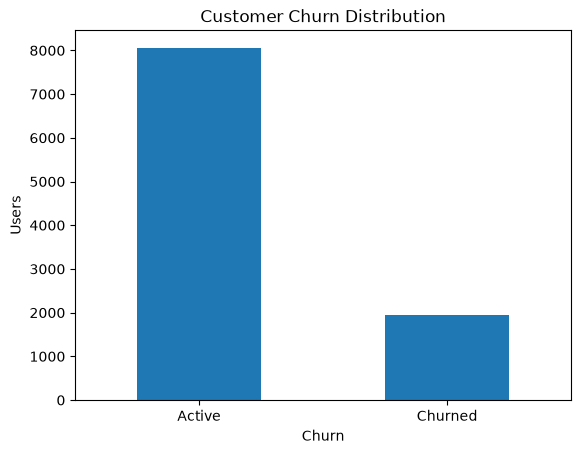

In [16]:
user_df["churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Users")

plt.xticks(
    [0,1],
    ["Active","Churned"],
    rotation=0
)

plt.show()

### Churn Label Definition

Because this project uses synthetic streaming data without true cancellation records,
a proxy churn label was created using user inactivity.

Users whose `days_since_last_stream` falls within the top 20% of inactivity
(85th percentile threshold) are labeled as churned.

This approach creates a balanced target suitable for demonstrating
machine learning techniques while remaining realistic for behavioral analytics.

In [23]:
features = [
    "total_streams",
    "avg_stream_duration_seconds",
    "skip_rate",
    "completion_rate",
    "unique_tracks",
    "unique_genres"
]

X = user_df[features]
y = user_df["churn"]

print(X.shape)
print(y.shape)

(10000, 6)
(10000,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [29]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7545


In [30]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[1474  137]
 [ 354   35]]
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1611
           1       0.20      0.09      0.12       389

    accuracy                           0.75      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.69      0.75      0.71      2000



## Model Evaluation

The initial model achieved perfect accuracy because the churn label was directly derived from
`days_since_last_stream`, creating target leakage.

To produce a more realistic evaluation, that feature was removed from the training data.

The resulting model achieved approximately 75% accuracy, demonstrating that predicting churn
from behavioral streaming metrics alone is substantially more challenging.

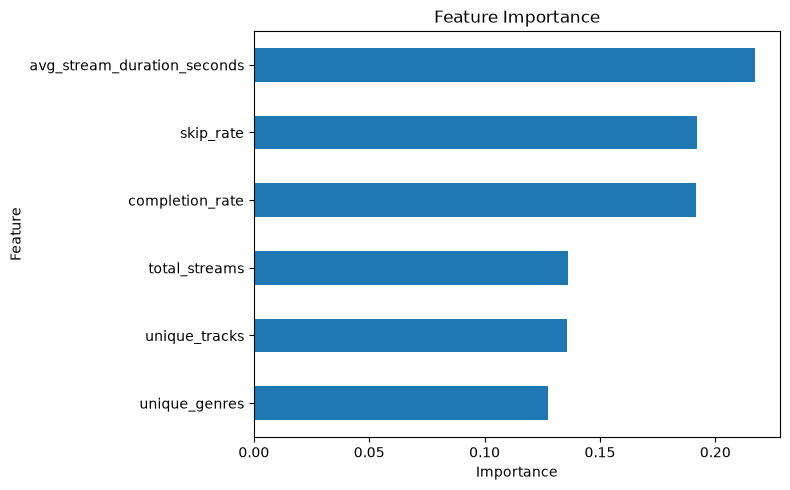

In [32]:
feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=features
    )
    .sort_values()
)

plt.figure(figsize=(8,5))

feature_importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()